In [1]:
!pip install -q tensorflow numpy matplotlib seaborn scikit-learn

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os, pathlib, tarfile, urllib.request, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


PART A: Computer Vision (Flower Classification)
A1: Load the dataset

In [4]:
FLOWERS_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
if not os.path.exists('flower_photos'):
    urllib.request.urlretrieve(FLOWERS_URL, 'flower_photos.tgz')
    with tarfile.open('flower_photos.tgz') as tar:
        tar.extractall('.', filter='data')

data_dir = pathlib.Path('flower_photos')
class_names = sorted(p.name for p in data_dir.iterdir() if p.is_dir())
num_classes = len(class_names)

paths, labels = [], []
for i, c in enumerate(class_names):
    for f in sorted((data_dir / c).glob('*.jpg')):
        paths.append(str(f)); labels.append(i)
paths, labels = np.array(paths), np.array(labels)

# reproducible shuffle, then 70 / 15 / 15 split
idx = np.random.default_rng(42).permutation(len(paths))
paths, labels = paths[idx], labels[idx]
n = len(paths); n_tr, n_va = int(0.70 * n), int(0.15 * n)
tr_p, tr_l = paths[:n_tr], labels[:n_tr]
va_p, va_l = paths[n_tr:n_tr + n_va], labels[n_tr:n_tr + n_va]
te_p, te_l = paths[n_tr + n_va:], labels[n_tr + n_va:]

print("Classes:", class_names)
print("Total images:", n)
print("Train/Val/Test sizes:", len(tr_p), len(va_p), len(te_p))

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Total images: 3670
Train/Val/Test sizes: 2569 550 551


A2: Explore the data

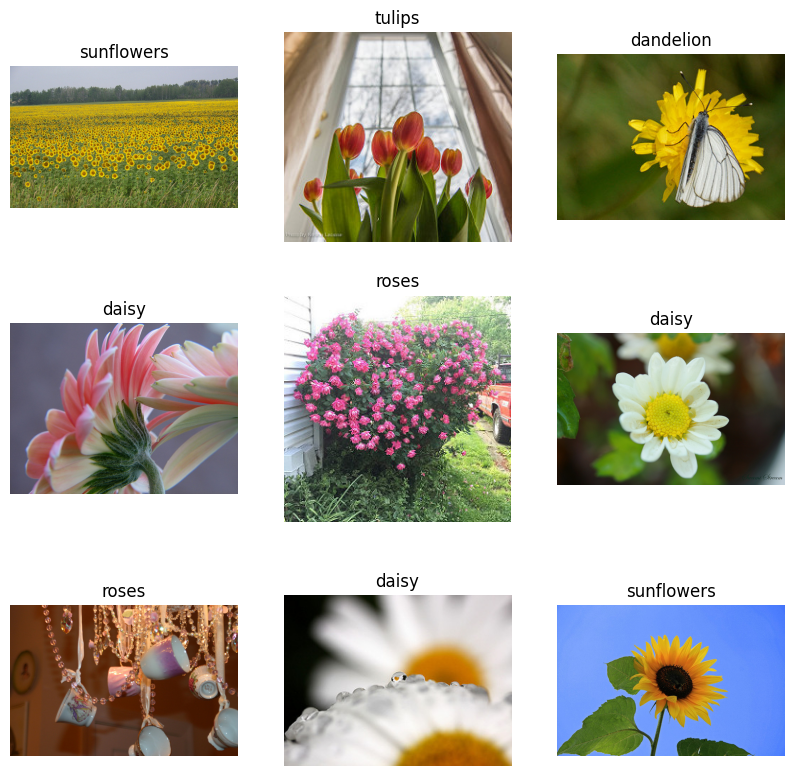

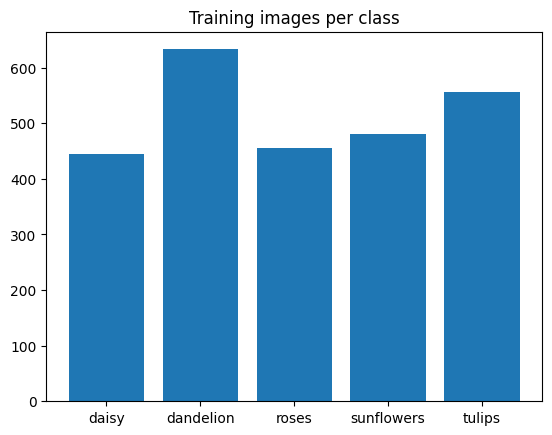

In [5]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(plt.imread(tr_p[i]))
    plt.title(class_names[tr_l[i]])
    plt.axis('off')
plt.show()

plt.bar(class_names, np.bincount(tr_l, minlength=num_classes))
plt.title("Training images per class")
plt.show()

A3: Preprocessing pipelines

In [6]:
IMG_SIZE, BATCH, AUTOTUNE = 224, 32, tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img, label

def make_ds(p, l, training=False):
    ds = tf.data.Dataset.from_tensor_slices((p, l)).map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train = make_ds(tr_p, tr_l, training=True)
val   = make_ds(va_p, va_l)
test  = make_ds(te_p, te_l)

A4: Build the model (MobileNetV2 transfer learning)

In [7]:
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augment(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes)(x)
cv_model = keras.Model(inputs, outputs)

cv_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])
cv_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

A5: Train phase 1 (base frozen)

In [8]:
cb1 = [keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
history = cv_model.fit(train, validation_data=val, epochs=10, callbacks=cb1)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.6263 - loss: 0.9641 - val_accuracy: 0.8036 - val_loss: 0.5721
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.8248 - loss: 0.4983 - val_accuracy: 0.8455 - val_loss: 0.4525
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.8560 - loss: 0.4064 - val_accuracy: 0.8600 - val_loss: 0.4076
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8680 - loss: 0.3638 - val_accuracy: 0.8636 - val_loss: 0.3885
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.8875 - loss: 0.3234 - val_accuracy: 0.8709 - val_loss: 0.3740
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8906 - loss: 0.3172 - val_accuracy: 0.8709 - val_loss: 0.3567
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.9077 - loss: 0.2793 - val_accuracy: 0.8727 - val_loss: 0.3545
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.9046 - loss: 0.2713 - val_accuracy: 0.8655

A6: Train phase 2 (fine-tuning)

In [9]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

cv_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

cb2 = [keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
history_ft = cv_model.fit(train, validation_data=val, epochs=10, callbacks=cb2)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 126ms/step - accuracy: 0.8077 - loss: 0.5241 - val_accuracy: 0.8709 - val_loss: 0.3726
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.8684 - loss: 0.3745 - val_accuracy: 0.8691 - val_loss: 0.3908
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.8883 - loss: 0.3310 - val_accuracy: 0.8727 - val_loss: 0.3844
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.8965 - loss: 0.2783 - val_accuracy: 0.8818 - val_loss: 0.3592
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.9105 - loss: 0.2604 - val_accuracy: 0.8855 - val_loss: 0.3412
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9183 - loss: 0.2385 - val_accuracy: 0.8800 - val_loss: 0.3228
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9190 - loss: 0.2334 - val_accuracy: 0.8855 - val_loss: 0.3163
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9229 - loss: 0.2207 - val_accura

A7: Training curves

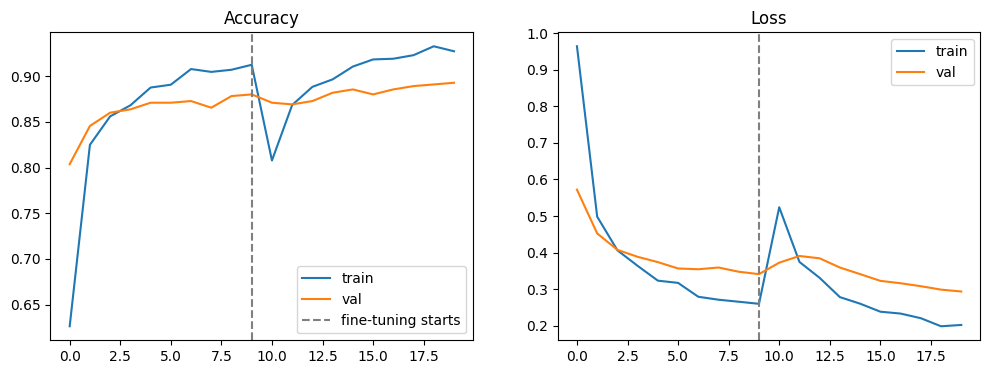

In [10]:
acc   = history.history['accuracy'] + history_ft.history['accuracy']
vacc  = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss  = history.history['loss'] + history_ft.history['loss']
vloss = history.history['val_loss'] + history_ft.history['val_loss']
split = len(history.history['accuracy']) - 1

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(acc, label='train'); ax[0].plot(vacc, label='val')
ax[0].axvline(split, ls='--', c='gray', label='fine-tuning starts')
ax[0].set_title('Accuracy'); ax[0].legend()
ax[1].plot(loss, label='train'); ax[1].plot(vloss, label='val')
ax[1].axvline(split, ls='--', c='gray')
ax[1].set_title('Loss'); ax[1].legend()
plt.show()

A8: Evaluate on the test set

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.8966 - loss: 0.2937
[Computer Vision] Test accuracy: 0.8966
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 303ms/step
              precision    recall  f1-score   support

       daisy       0.82      0.95      0.88        84
   dandelion       0.96      0.89      0.93       139
       roses       0.85      0.89      0.87        90
  sunflowers       0.94      0.89      0.91       115
      tulips       0.89      0.88      0.89       123

    accuracy                           0.90       551
   macro avg       0.89      0.90      0.89       551
weighted avg       0.90      0.90      0.90       551



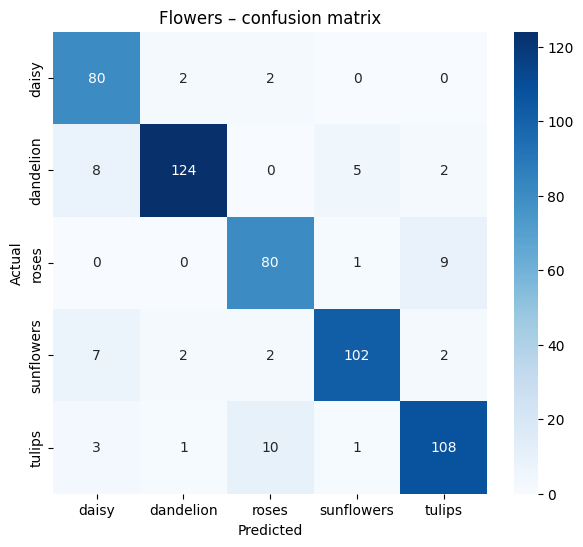

In [11]:
cv_loss, cv_acc = cv_model.evaluate(test)
print(f"[Computer Vision] Test accuracy: {cv_acc:.4f}")

y_true = te_l
y_pred = np.argmax(cv_model.predict(test), axis=1)
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Flowers – confusion matrix')
plt.show()

A9: Sample predictions

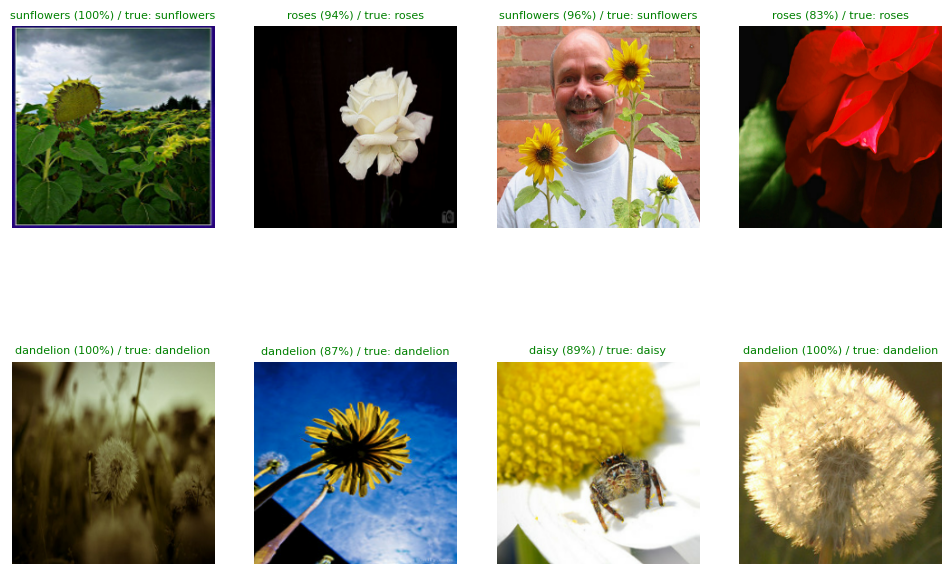

In [12]:
plt.figure(figsize=(12, 8))
for i in range(8):
    img, label = load_image(te_p[i], te_l[i])
    probs = tf.nn.softmax(cv_model.predict(tf.expand_dims(img, 0), verbose=0)[0]).numpy()
    pred = int(np.argmax(probs))
    plt.subplot(2, 4, i + 1)
    plt.imshow(img.numpy().astype('uint8')); plt.axis('off')
    plt.title(f"{class_names[pred]} ({probs[pred]:.0%}) / true: {class_names[int(label)]}",
              color='green' if pred == int(label) else 'red', fontsize=8)
plt.show()

A10: Save the model and check it reloads

In [13]:
cv_model.save('flower_classifier.keras')
loaded_cv = keras.models.load_model('flower_classifier.keras')
print("Reloaded flower model test accuracy:", loaded_cv.evaluate(test, verbose=0)[1])

Reloaded flower model test accuracy: 0.8965517282485962


In [14]:
from google.colab import files
files.download('flower_classifier.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PART B: Text Classification (IMDB Sentiment)
B1: Load the dataset

In [15]:
IMDB_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
if not os.path.exists('aclImdb'):
    urllib.request.urlretrieve(IMDB_URL, 'aclImdb_v1.tar.gz')
    with tarfile.open('aclImdb_v1.tar.gz') as tar:
        tar.extractall('.', filter='data')
shutil.rmtree('aclImdb/train/unsup', ignore_errors=True)   # unlabeled reviews, not needed

TXT_BATCH = 64
raw_train = keras.utils.text_dataset_from_directory(
    'aclImdb/train', batch_size=TXT_BATCH, validation_split=0.2, subset='training', seed=42)
raw_val = keras.utils.text_dataset_from_directory(
    'aclImdb/train', batch_size=TXT_BATCH, validation_split=0.2, subset='validation', seed=42)
raw_test = keras.utils.text_dataset_from_directory(
    'aclImdb/test', batch_size=TXT_BATCH, shuffle=False)

text_classes = raw_train.class_names
print("Classes:", text_classes)

for texts, labs in raw_train.take(1):
    for t_, l_ in list(zip(texts.numpy(), labs.numpy()))[:3]:
        print(f"[{text_classes[int(l_)]}]", t_.decode()[:200], "...")

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.
Classes: ['neg', 'pos']
[pos] First of all, I liked very much the central idea of locating the '' intruders'', Others in the fragile Self, on various levels - mainly subconscious but sometimes more allegorical. In fact the intrude ...
[neg] David Mamet is a very interesting and a very un-equal director. His first movie 'House of Games' was the one I liked best, and it set a series of films with characters whose perspective of life change ...
[neg] After Harry Reems' teenage girlfriend is raped by Zebbedy Colt (The Night-Walker), Reems becomes despondent and consoles himself by having sex with some lesbians. Meanwhile, Colt, who carries a cane a ...


B2: Explore the data

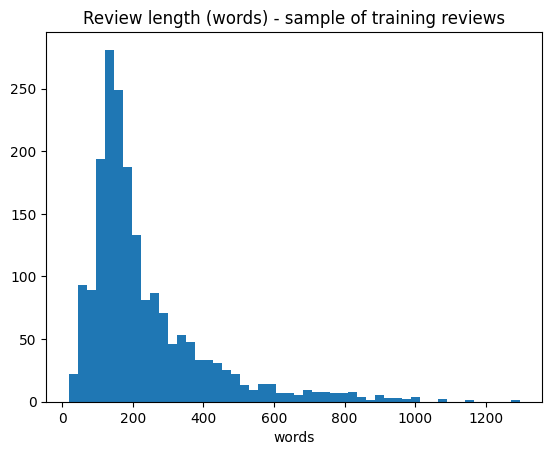

Median length: 176 words


In [16]:
lengths = []
for texts, _ in raw_train.take(30):
    lengths += [len(t_.decode().split()) for t_ in texts.numpy()]
plt.hist(lengths, bins=50)
plt.title("Review length (words) - sample of training reviews")
plt.xlabel("words"); plt.show()
print("Median length:", int(np.median(lengths)), "words")

B3: Input pipelines

In [17]:
txt_train = raw_train.prefetch(AUTOTUNE)
txt_val   = raw_val.prefetch(AUTOTUNE)
txt_test  = raw_test.prefetch(AUTOTUNE)

B4: Build the model (TextVectorization + Embedding + BiLSTM)

In [18]:
VOCAB, SEQ_LEN = 20000, 256

vectorizer = layers.TextVectorization(max_tokens=VOCAB, output_sequence_length=SEQ_LEN)
vectorizer.adapt(txt_train.map(lambda t, l: t))

txt_in = keras.Input(shape=(), dtype=tf.string)
x = vectorizer(txt_in)
x = layers.Embedding(VOCAB, 64, mask_zero=True)(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(32, activation='relu')(x)
txt_out = layers.Dense(1, activation='sigmoid')(x)
text_model = keras.Model(txt_in, txt_out)

text_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='binary_crossentropy', metrics=['accuracy'])
text_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 256)       │          0 │ input_layer_3[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 64)   │  1,280,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 256)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     66,048 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,128 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,350,209 (5.15 MB)

 Trainable params: 1,350,209 (5.15 MB)

 Non-trainable params: 0 (0.00 B)

B5: Train

In [20]:
txt_cb = [keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)]
txt_history = text_model.fit(txt_train, validation_data=txt_val, epochs=6, callbacks=txt_cb)

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9549 - loss: 0.1301 - val_accuracy: 0.8706 - val_loss: 0.4163
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9730 - loss: 0.0819 - val_accuracy: 0.8560 - val_loss: 0.4962
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9851 - loss: 0.0455 - val_accuracy: 0.8652 - val_loss: 0.5656


B6: Training curves

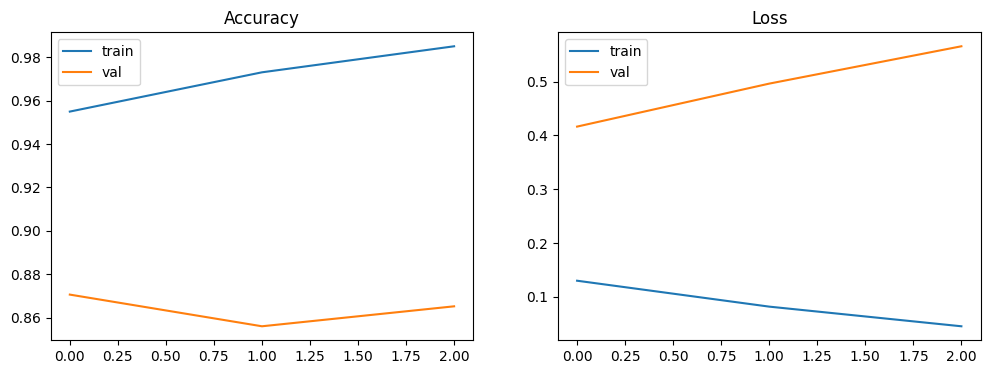

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(txt_history.history['accuracy'], label='train')
ax[0].plot(txt_history.history['val_accuracy'], label='val')
ax[0].set_title('Accuracy'); ax[0].legend()
ax[1].plot(txt_history.history['loss'], label='train')
ax[1].plot(txt_history.history['val_loss'], label='val')
ax[1].set_title('Loss'); ax[1].legend()
plt.show()

B7: Evaluate on the test set

391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8432 - loss: 0.5079
[Text Classification] Test accuracy: 0.8432
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step
              precision    recall  f1-score   support

         neg       0.82      0.88      0.85     12500
         pos       0.87      0.81      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



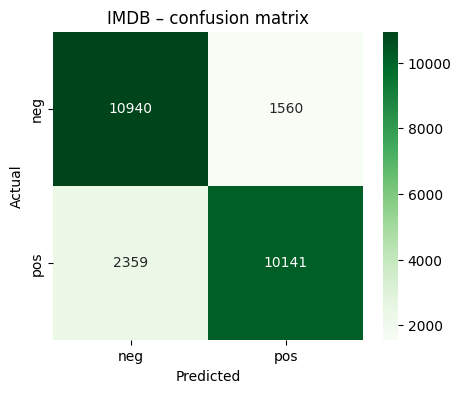

In [22]:
txt_loss, txt_acc = text_model.evaluate(txt_test)
print(f"[Text Classification] Test accuracy: {txt_acc:.4f}")

t_true = np.concatenate([y.numpy() for _, y in txt_test])
t_pred = (text_model.predict(txt_test).ravel() > 0.5).astype(int)
print(classification_report(t_true, t_pred, target_names=text_classes))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(t_true, t_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=text_classes, yticklabels=text_classes)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('IMDB – confusion matrix')
plt.show()

B8:  custom reviews

In [23]:
samples = [
    "An absolutely wonderful film. Brilliant acting and a moving story.",
    "Terrible movie. Boring plot, awful dialogue, a complete waste of time.",
    "It had some good moments but overall it was disappointing.",
    "I loved every minute of it, easily one of the best movies this year!",
]
probs = text_model.predict(tf.constant(samples), verbose=0).ravel()
for s, p in zip(samples, probs):
    print(f"{'POSITIVE' if p > 0.5 else 'NEGATIVE'} ({p:.2f})  ->  {s}")

POSITIVE (0.99)  ->  An absolutely wonderful film. Brilliant acting and a moving story.
NEGATIVE (0.00)  ->  Terrible movie. Boring plot, awful dialogue, a complete waste of time.
NEGATIVE (0.12)  ->  It had some good moments but overall it was disappointing.
POSITIVE (0.99)  ->  I loved every minute of it, easily one of the best movies this year!


B9: Save the text model and check it reloads

In [24]:
text_model.save('imdb_sentiment_classifier.keras')
loaded_txt = keras.models.load_model('imdb_sentiment_classifier.keras')
print("Reloaded text model test accuracy:", loaded_txt.evaluate(txt_test, verbose=0)[1])
print("Raw-text prediction:", loaded_txt.predict(tf.constant(["What a fantastic movie!"]), verbose=0).ravel())

Reloaded text model test accuracy: 0.8432400226593018
Raw-text prediction: [0.9182859]


In [25]:
print("=" * 50)
print(f"Computer Vision (flowers)  test accuracy: {cv_acc:.2%}")
print(f"Text Classification (IMDB) test accuracy: {txt_acc:.2%}")
print("=" * 50)

Computer Vision (flowers)  test accuracy: 89.66%
Text Classification (IMDB) test accuracy: 84.32%


In [26]:
from google.colab import files
files.download('imdb_sentiment_classifier.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>